In [ ]:
import os
import gc
import re
import glob
import tqdm
import pickle
from os.path import exists

import scanpy as sc
import cell2fate as c2f
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import torch

import gseapy as gp

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

palette_25 = [
    "#ffd92f",  # yellow
    "#bcbd22",  # olive

    "#ff7f0e",  # orange

    "#d62728",  # red
    "#e377c2",  # pink
    "#8c564b",  # brown
    "#9467bd",  # purple

    "#2ca02c",  # green
    "#7f7f7f",  # gray

    "#17becf",  # cyan
    "#003f5c",  # dark blue
    "#ffa600",  # amber
    "#2f4b7c",  # indigo
    "#a05195",  # magenta
    "#665191",  # violet
    "#d45087",  # rose
    "#f95d6a",  # coral
    "#00cc99",  # teal-green

    # --- added colors ---
    "#66c2a5",  # mint
    "#fc8d62",  # peach
    "#8da0cb",  # lavender-blue
    "#e78ac3",  # light pink
    "#a6d854",  # lime
    "#e5c494",  # sand
]

from matplotlib.colors import ListedColormap
cmap25 = ListedColormap(palette_25, name="distinct25")

Global seed set to 0


In [ ]:
wd = '../data/cell2fate_trajectories/'
outdir = '../data/trajectories/plots/'

# Plotting

In [ ]:
plot_df = pd.read_csv(os.path.join(wd, "all_top_genes_labelled.csv"), index_col=0)
top_genes = pd.read_csv(os.path.join(wd, "all_top_genes_latest.csv"), index_col=0)

# get MM markers:
with open(wd+"factor_genes_latest.pkl", "rb") as f:
    factor_gene_dict = pickle.load(f)

In [ ]:
# malignant adata
adata = sc.read_h5ad('../../../data/GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad')
adata = adata[adata.obs['cell_status']=='Malignant',].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
# neftel
score_list = []
for m in factor_gene_dict.keys():
    print(m)
    sc.tl.score_genes(adata, factor_gene_dict[m], score_name=str(m)+'_score', use_raw=False)
    score_list.append(str(m)+'_score')

Cycling
NPC-neuronal-like 1
Gliosis-hypoxia
AC-gliosis-like 2
NPC-OPC-like 2
AC-gliosis-like 1
NPC-neuronal-like 2
NPC-OPC-like 1
AC-NPC-OPC-like 1
AC-progenitor-like
NPC-neuronal-like 3
OPC-like


In [ ]:
annotation = {
    0:'Cycling',
    1:'NPC-neuronal-like 1',
    2:'Gliosis-hypoxia',
    3:'AC-gliosis-like 2',
    4:'NPC-OPC-like 2', # oligo-like
    5:'AC-gliosis-like 1',
    6:'NPC-neuronal-like 2',
    7:'NPC-OPC-like 1',
    8:'AC-NPC-OPC-like 1', # (NPC-neuronal)
    9:'AC-progenitor-like',  
    10:'NPC-neuronal-like 3', 
    11:'OPC-like', # (NPC-OPC)
}

## Latent time estimates

In [ ]:
gc.collect()

1707

In [ ]:
# latent time 

os.chdir(path)
files = glob.glob('*.csv')
files = [i for i in files if 'latent_time' in i]

latent_time = []
for file in files:
    latent_time.append(pd.read_csv(file, index_col=0))
latent_time = pd.concat(latent_time)

latent_time['module'] = latent_time['donor_id']+'_'+latent_time['clone'].astype(str)+'_'+latent_time['modules'].astype(str)
latent_time = latent_time#.drop(['donor_id', 'clone', 'modules'], axis=1)


module_df = plot_df[['label']].reset_index().rename(columns={'index':'module'})\
    .merge(latent_time, on = 'module')
module_df['annotation'] = [annotation[i] for i in module_df['label']]

In [ ]:
ordered = module_df.groupby(['annotation', 'label'], 
                  as_index=False)['latent_time'].mean().sort_values('latent_time')

ordered

,annotation,label,latent_time
11,OPC-like,11,0.038446
9,NPC-neuronal-like 2,6,0.147470
7,NPC-OPC-like 2,4,0.308770
6,NPC-OPC-like 1,7,0.330198
10,NPC-neuronal-like 3,10,0.391986
5,Gliosis-hypoxia,2,0.469363
3,AC-progenitor-like,9,0.474248
1,AC-gliosis-like 1,5,0.474447
8,NPC-neuronal-like 1,1,0.561258
4,Cycling,0,0.582803


In [ ]:
balanced_clones = ['AT10_2', 'AT11_1', 'AT9_2', 'AT9_1', 'AT10_1', 'AT5_2', 'AT4_2', 'AT9_4',
'AT9_0', 'AT15_6', 'AT15_4', 'AT15_3', 'AT15_2', 'AT15_0', 'AT10_0', 'AT4_1',
'AT4_0', 'AT6_0', 'AT15_5']

module_df['clone_id'] = module_df['donor_id']+'_'+module_df['clone'].astype(str)
ordered = module_df[module_df['clone_id'].isin(balanced_clones)]\
    .groupby(['annotation', 'label'], 
                  as_index=False)['latent_time'].mean().sort_values('latent_time')

In [ ]:
ordered

,annotation,label,latent_time
11,OPC-like,11,0.049431
9,NPC-neuronal-like 2,6,0.136001
6,NPC-OPC-like 1,7,0.299709
7,NPC-OPC-like 2,4,0.302891
10,NPC-neuronal-like 3,10,0.391986
8,NPC-neuronal-like 1,1,0.542182
4,Cycling,0,0.556999
1,AC-gliosis-like 1,5,0.561423
3,AC-progenitor-like,9,0.569476
5,Gliosis-hypoxia,2,0.628085


<AxesSubplot:ylabel='annotation_granular'>

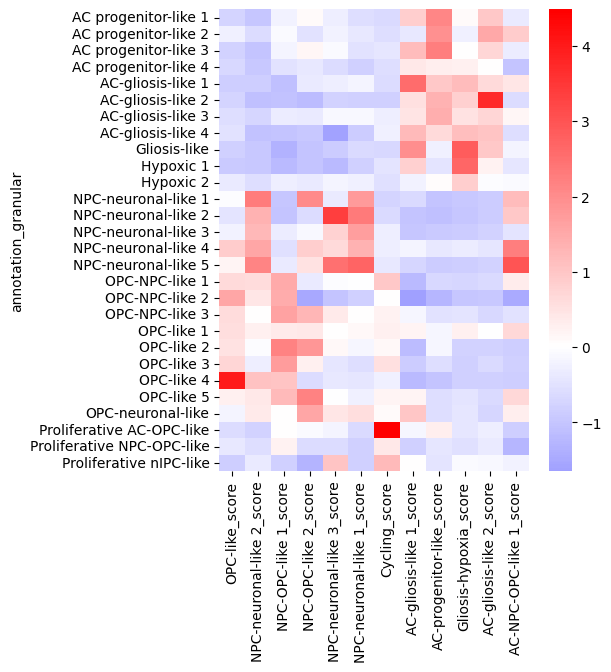

In [ ]:
module_scores = adata.obs\
    .groupby(['annotation_granular'])[score_list].mean()\
    .apply(zscore, axis=0)

module_scores = module_scores[[i+'_score' for i in ordered['annotation']]]

plt.figure(figsize=(5, 6))
sns.heatmap(module_scores, cmap = 'bwr', center=0)

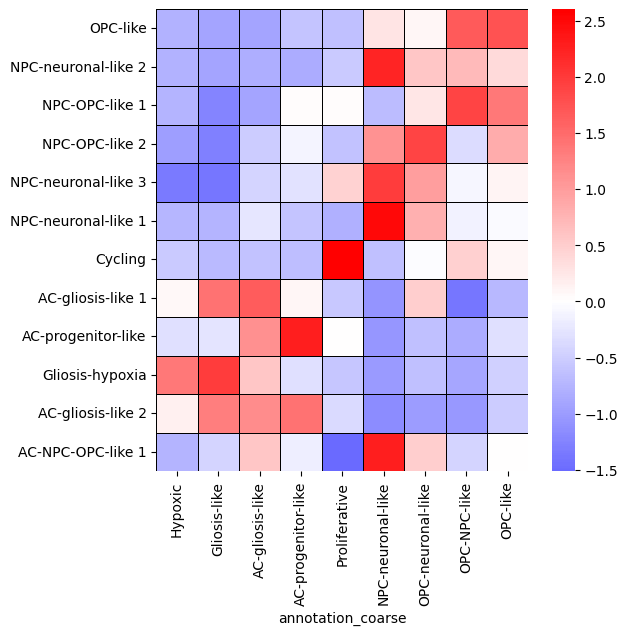

In [ ]:
module_scores = adata.obs\
    .groupby(['annotation_coarse'])[score_list].mean()\
    .apply(zscore, axis=0)

module_scores = module_scores[[i+'_score' for i in ordered['annotation']]]
module_scores.columns = [re.sub('_score', '', i) for i in module_scores.columns]
module_scores = module_scores.T

cols = [
'Hypoxic', 'Gliosis-like',
'AC-gliosis-like', 'AC-progenitor-like', 'Proliferative', 
'NPC-neuronal-like', 'OPC-neuronal-like', 'OPC-NPC-like', 'OPC-like', 

]

module_scores = module_scores[cols]

plt.figure(figsize=(6, 6))
sns.heatmap(module_scores, cmap = 'bwr', center=0,
           linewidths=0.5, linecolor="black")
plt.show()

In [ ]:
module_scores.to_csv('../../../data/EDFig8/EDFig8a2.csv')

In [ ]:
#plot_df_b = plot_df.T[plot_df.T.index.isin(['MYRF', 'ASCL1', 'SOX10', 'HIVEP3', 'FOS'])].T
plot_df_out = plot_df.drop('label', axis=1)

genes_counts = plot_df.groupby('label').sum()
gene_total = plot_df.reset_index().groupby('label')['index'].count()
genes_counts = genes_counts.divide(gene_total, axis=0)

genes_retain = []
for label in genes_counts.index:
    s = genes_counts[genes_counts.index==label].T
    top = s[label].quantile(0.99)
    s = s[s[label]>top]
    genes_retain.append(s.index.tolist())
genes_retain = list(set([i for l in genes_retain for i in l]))

plot_df_out = plot_df_out[genes_retain]


plot_df_b = plot_df_out.reset_index()\
    .merge(plot_df[['label']].reset_index(), on = 'index')\
    .set_index('index')

In [ ]:
plot_df_b = plot_df_b.reset_index()\
        .merge(ordered, on = 'label')\
        .set_index('index')

In [ ]:
# reorder 
order_map = {k: i for i, k in enumerate(ordered["label"])}

plot_df_b = plot_df_b.assign(
    _order=plot_df_b["label"].map(order_map)
).sort_values("_order").drop(columns="_order")

In [ ]:
plot_df_b = plot_df_b.drop(['latent_time', 
                            'annotation',
                            'label'], axis=1).T

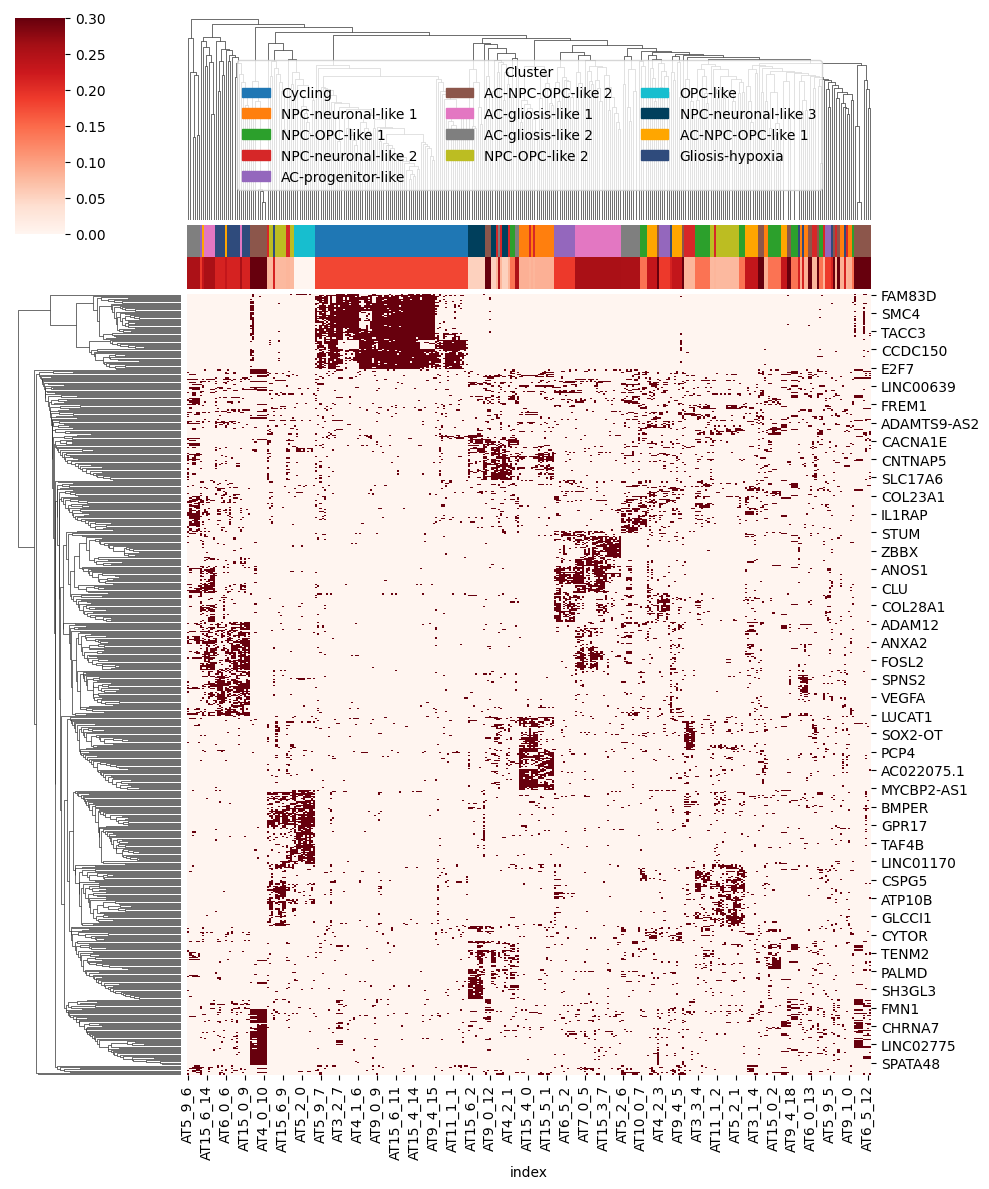

In [ ]:
import matplotlib.patches as mpatches

g = sns.clustermap(plot_df_b, cmap='Reds', 
               col_cluster=True,
               col_colors=[label_colors, time_colors],
               figsize=(10, 12), vmax=0.3
)

named_dict = {
    annotation.get(k, k): v
    for k, v in cluster_to_color.items()
}

handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in named_dict.items()
]

g.ax_heatmap.legend(
    handles=handles,
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),  # above plot
    ncol=3,
    borderaxespad=0,
)

## Overlap plot

In [ ]:
gene_counts = plot_df.groupby('label').sum()
factor_counts = plot_df.reset_index().groupby('label')['index'].count()
factor_gene_prec = gene_counts.divide(factor_counts, axis=0).T

In [ ]:
# then factor plot
top_gene_list = []
top_gene_dict = {}
for m in ordered['annotation']:
    l = [i for i in factor_gene_dict[m][:20] if i not in top_gene_list]
    top_gene_list.extend(l)
    top_gene_dict[m] = l

In [ ]:
genes = [
    "PRC1",
    "PBK",
    "BRIP1",
    "CENPK",
    "ID3",
    "SERPINA3",
    "BBOX1",
    "GFAP",
    "EMP1",
    "HIVEP3",
    "POSTN",
    "CPNE4",
    "SERPINE1",
    "ANGPTL4",
    "HILPDA",
    "MYO5C",
    "XYLT1",
    "MMP2",
    "CCNIP1",
    "CFAP43",
    "RBMS3",
    "GABRA5",
    "MYT1L",
    "SYT1",
    "CUX2",
    "GRIN3A",
    "RBFOX1",
    "GRIN2B",
    "ARX",
    "SLIT3",
    "DLX5",
    "FERMT1",
    "DLL3",
    "MYRF",
    "MOG",
    "MBP",
]

In [ ]:
top_gene_list = [i for i in top_gene_list if i in genes]

In [ ]:
top_gene_list_plot = [
 # OPC-like
 'MYRF',
 'MOG',
 'MBP',
 'FERMT1',
 # NPC 2 - possibly more NPC-OPC
 'GPR17',
 'FA2H',
 'DCX',
 # OPC-NPC 1
 'DLL3',
 'VIPR2',
 # OPC-NPC 2
 'KCNIP1',
 'CA10',
 # NPC-neuronal-like 3
 'ARX',
 'DLX6',
 # NPC-neuronal-like 1
 'SYT1',
 'CUX2',
 'MYT1L', # remove?
 # Cycling
 'CENPI',    
 'PBK',
 # AC-gliosis-like 1
 'IL1RAP',
 'ITGA3',
 'HIVEP3',
 # AC prog
 'AQP4',
 'ALDH1L1',
 'SLC1A3',
 # Gliosis-hypoxia
 'ANGPTL4',
 'SERPINE1',
 'HILPDA',
 # AC-gliosis-like 2
 'GFAP',
 'ABCC3',
 'CFAP54',
 # AC-NPC-OPC-like 2
 'HMGA2',
 'FRAS1',
 'NRG3'
]

In [ ]:
perc_threshold = 0.3
factor_rank_df = []
for f in factor_gene_prec.columns:
    factor_ranks = factor_gene_prec[f].sort_values(ascending=False)
    factor_ranks.name = f
    factor_rank_df.append(factor_ranks)
factor_rank_df = pd.concat(factor_rank_df, axis=1)

In [ ]:
# get color bar - label
named_dict = {
 'Cycling': '#ffd92f',
 'NPC-neuronal-like 1': '#e377c2',
 'Gliosis-hypoxia': '#ff7f0e',
 'AC-gliosis-like 2': '#d62728',
 'NPC-OPC-like 2': '#bcbd22',
 'AC-gliosis-like 1': '#8c564b',
 'NPC-neuronal-like 2': '#5A14A5',
 'NPC-OPC-like 1': '#2ca02c',
 'AC-NPC-OPC-like 1': '#7f7f7f',
 'AC-progenitor-like': '#003f5c',
 'NPC-neuronal-like 3': '#ff1493',  # bright magenta
 'OPC-like': '#00bfff'              # bright sky blue
}


clusters = sorted(set(ordered['annotation']))
label_colors = ordered['annotation'].map(named_dict)

In [ ]:
# get color bar - time
col_values = ordered['latent_time']

norm = matplotlib.colors.Normalize(
    vmin=col_values.min(),
    vmax=col_values.max()
)

cmap = matplotlib.cm.get_cmap("Reds")

time_colors = col_values.map(lambda x: cmap(norm(x)))

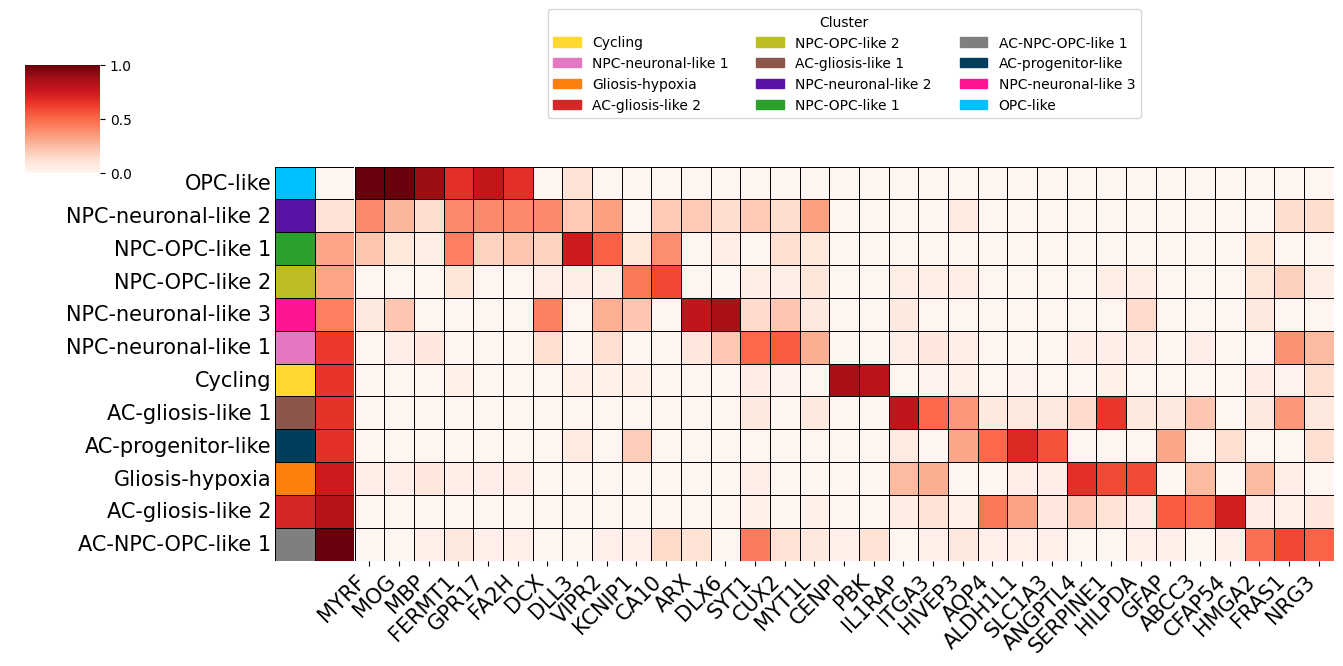

In [ ]:
import matplotlib.patches as mpatches

factor_rank_df_p = factor_rank_df[ordered['label']].T[top_gene_list_plot].T

factor_rank_df_p.columns = [annotation[i] for i in factor_rank_df_p.columns]

g = sns.clustermap(factor_rank_df_p.T, cmap='Reds', 
               row_cluster=False,
               col_cluster=False,
               row_colors=[label_colors, time_colors],
               figsize=(15, 6),
               yticklabels=True,
               linewidths=0.5,
               linecolor="black"
)

handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in named_dict.items()
]

g.ax_heatmap.legend(
    handles=handles,
    title="Cluster",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.4),  # above plot
    ncol=3,
    borderaxespad=0,
)

import matplotlib.ticker as mticker
ax = g.ax_heatmap
# rows (y)
nrows = g.data2d.shape[0]
ypos = np.arange(nrows) + 0.5
ax.yaxis.set_major_locator(mticker.FixedLocator(ypos))
ax.set_yticklabels(g.data2d.index, rotation=0)

# columns (x) — optional
ncols = g.data2d.shape[1]
xpos = np.arange(ncols) + 0.5
ax.xaxis.set_major_locator(mticker.FixedLocator(xpos))
ax.set_xticklabels(g.data2d.columns, rotation=45, ha="right")

g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_label_position("left")

# optional: control size so they’re readable
ax.tick_params(axis="y", labelsize=15, pad = 60, length=0)
ax.tick_params(axis="x", labelsize=15)

#plt.savefig(outdir+'MM_factor_plot.pdf')
plt.show()

In [ ]:
factor_rank_df_p.T.to_csv('../../../data/EDFig8/EDFig8a1.csv')

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

def listed_cmap_from_hex(hex_color, n=256, min_color="white"):
    start = np.array(mcolors.to_rgb(min_color))
    end = np.array(mcolors.to_rgb(hex_color))

    colors = [
        start + (end - start) * i / (n - 1)
        for i in range(n)
    ]

    return mcolors.ListedColormap(colors)

MM_cmaps = {}
for k in named_dict:
    MM_cmaps[k] = listed_cmap_from_hex(named_dict[k])

In [ ]:
named_dict

{'Cycling': '#ffd92f',
 'NPC-neuronal-like 1': '#e377c2',
 'Gliosis-hypoxia': '#ff7f0e',
 'AC-gliosis-like 2': '#d62728',
 'NPC-OPC-like 2': '#bcbd22',
 'AC-gliosis-like 1': '#8c564b',
 'NPC-neuronal-like 2': '#5A14A5',
 'NPC-OPC-like 1': '#2ca02c',
 'AC-NPC-OPC-like 1': '#7f7f7f',
 'AC-progenitor-like': '#003f5c',
 'NPC-neuronal-like 3': '#ff1493',
 'OPC-like': '#00bfff'}

## Get table of metamodule info

In [ ]:
libraries = [
    "MSigDB_Hallmark_2020",
    "MSigDB_Oncogenic_Signatures",
    "GO_Biological_Process_2021",
    "Reactome_2022",
    "Human_Phenotype_Ontology",
    "KEGG_2026",
]

In [ ]:
all_results = []
for f in factor_gene_dict.keys():
    genes = factor_gene_dict[f]
    if len(genes) < 5:
        continue

    for lib in libraries:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=lib,
            organism="Human",
            outdir=None,
            cutoff=0.1,
        )

        res = enr.results.copy()
        res["factor_id"] = f
        all_results.append(res)

ora_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

In [ ]:
set(ora_df[ora_df['Adjusted P-value']<=0.05]['factor_id'])

{'AC-NPC-OPC-like 1',
 'AC-gliosis-like 1',
 'AC-gliosis-like 2',
 'AC-progenitor-like',
 'Cycling',
 'Gliosis-hypoxia',
 'NPC-OPC-like 1',
 'NPC-OPC-like 2',
 'NPC-neuronal-like 1',
 'NPC-neuronal-like 2',
 'NPC-neuronal-like 3',
 'OPC-like'}

In [ ]:
annotation = {
    0:'Cycling',
    1:'NPC-neuronal-like 1',
    2:'Gliosis-hypoxia',
    3:'AC-gliosis-like 2',
    4:'NPC-OPC-like 2', # oligo-like
    5:'AC-gliosis-like 1',
    6:'NPC-neuronal-like 2',
    7:'NPC-OPC-like 1',
    8:'AC-NPC-OPC-like 1', # (NPC-neuronal)
    9:'AC-progenitor-like',  
    10:'NPC-neuronal-like 3', 
    11:'OPC-like', # (NPC-OPC)
}

reversed_d = {value: key for key, value in annotation.items()}

In [ ]:
metamodule_table = []
for factor in set(ora_df['factor_id']):
    subset = ora_df[
        (ora_df['Adjusted P-value']<=0.05) & 
        (ora_df['factor_id']==factor)]

    # select gene set
    subset = subset[subset['Gene_set']=='GO_Biological_Process_2021']

    MetaModule = reversed_d[factor]
    SharedGenes = ', '.join(factor_gene_dict[factor])
    EnrichedPathways = ', '.join(subset['Term'])

    metamodule_table.append(
        pd.DataFrame({
        'MetaModule':MetaModule,
        'annotation':factor,
        'Shared Genes':SharedGenes,
        'Enriched Pathways':EnrichedPathways}, index = [0])
    )
metamodule_table = pd.concat(metamodule_table, ignore_index = True)

In [ ]:
metamodule_table.sort_values('MetaModule')\
    .to_csv(outdir+'MM_table.csv')